# Well-posed LFR-based model augmentation structure
The LFR-based model augmentation structure is a generalization of all existing model augmentation formulations. This generality is achieved by introducing the interconnection matrix, i.e., the LFR matrix, into the optimization variables. However, due to this flexible parametrization, an algebraic loop appears in the model structure, which needs to be handled carefully. In previous examples, we have seen two possible options: first, when the $D_\mathrm{zw}=0$ constraint is applied, and secondly, when $D_\mathrm{zw}$ is constrained to be strictly lower triangular. These relatively simple approaches guarantee the well-posedness of the LFR-based structure; however, also limit the number of augmentation structures that can be represented by the LFR-based formulation. The implementation provides a more general structure, which guarantees well-posedness by parametrization and solves the "algebraic loop" with *fixed-point iterations* (FPI). The direct parametrization ensures that the FPI always converges. This parametrization uses the Lipschitz constant of the baseline model, hence, that needs to be provided.

In [1]:
# basic imports and setting JAX options
import numpy as np
import jax
from matplotlib import pyplot as plt
from model_augmentation_jax import LinearTimeInvariantSystem, StaticWellPosedLFRAugmentation, \
    StaticContractingLFRAugmentation, DynamicLFRAugmentation
from model_augmentation_jax.utils import NRMSE_loss, compute_normalization_constants


jax.config.update('jax_platform_name', 'cpu')
if not jax.config.jax_enable_x64:
    jax.config.update("jax_enable_x64", True)  # Enable 64-bit computations

# Generate or load data
np.random.seed(0)
U = np.random.normal(size=10_000) # Input sequence
x = [0, 0] # Initial state
ylist = [] # Output sequence
for uk in U:
    ylist.append(x[0] + np.random.normal(loc=0., scale=0.01))  # Compute output
    x = 0.9 * x[0] + 0.1 * x[1] + 0.1 * uk + 0.02 * x[0] * x[1], \
       -0.2 * x[0] + 0.95 * x[1] + 0.05 * uk - 0.1 * x[0]**3 # Advance state

# Split dataset
Y = np.array(ylist)
Y_train = Y[:9000]
Y_test = Y[9000:]
U_train = U[:9000]
U_test = U[9000:]

For simplicity, we will use the LTI baseline model from example 0.

In [2]:
# create LTI baseline model (with approximate params)
A_mx = np.array([[0.88, 0.11], [-0.2, 0.94]])
B_mx = np.array([[0.1], [0.]])
C_mx = np.array([[1., 0.]])
fp_model = LinearTimeInvariantSystem(A=A_mx, B=B_mx, C=C_mx)

# simulate baseline model to approximate constants for normalization
Yhat_train_base, Xhat_train_base = fp_model.simulate(U_train)  # starts from x0 = 0
norm = compute_normalization_constants(U_train, Y_train, Xhat_train_base)

# calculate Lipschitz constant
L_base = np.linalg.norm(np.hstack((A_mx, B_mx)), 2)
print(f"Lipschitz constant of the baseline model: {np.maximum(L_base, 1.)}")  # (we now that the Lipschitz constant of the output map is 1)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Lipschitz constant of the baseline model: 1.0


When creating the model, the fixed-point iteration settings and the Lipschitz constant can be provided, otherwise everything is the same as before. Importantly, Lipschitz continuity is also essential for the learning component, which is enforced via regularization. the regularization coefficient needs to be set by using the `set_regularization_terms` method.

In [ ]:
# create augmented model
model = StaticWellPosedLFRAugmentation(known_sys=fp_model, hidden_layers=2, nodes_per_layer=8, activation="tanh", nz=2, nw=2, lipschitz_const=1., norm_dict=norm, fpi_n_max=10, fpi_tol=1e-4)

# set training options
model.set_optimization_parameters(adam_epochs=100, lbfgs_epochs=500, train_x0=True, verbosity=50)

# set ANN Lipschitz regularization
model.set_regularization_terms(ann_lipschitz_regul_coeff=0.1)

# train the model
model.fit(Y_train, U_train)

Note that the direct parametrization applies the Cayley transform to calculate the $D_\mathrm{zw}$ matrix, which makes training and simulation computationally somewhat more demanding compared to the simple LFR-based approach.

In [4]:
print(f"Model training finished in {model.t_solve} seconds.")

Model training finished in 17.427464962005615 seconds.


Note that `model.simulate` now also returns the number of fixed-point iterations required at each time step, as well as the approximated residuals of the FPI.

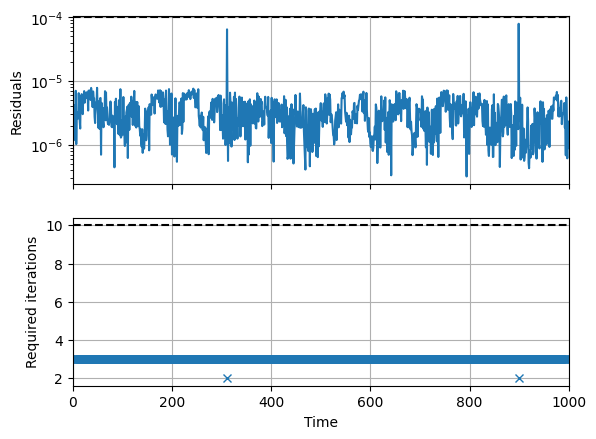

In [5]:
# estimate initial state based on first 10 samples of the test data
x0_test = model.learn_x0(U_test[:10], Y_test[:10], verbosity=False)

# simulate model
Yhat_test, _, iters, residuals = model.simulate(U_test, X0=x0_test)

# first, plot the fixed-point iterations during test
fig, ax = plt.subplots(2, 1, sharex=True)
ax[0].semilogy(residuals)
ax[0].axhline(1e-4, ls="--", color="k")
ax[0].set_ylabel("Residuals")
ax[0].grid()
ax[0].set_xlim([0, 1000])

ax[1].plot(iters, 'x')
ax[1].axhline(10, ls="--", color="k")
ax[1].set_ylabel("Required iterations")
ax[1].set_xlabel("Time")
ax[1].grid()
plt.show()

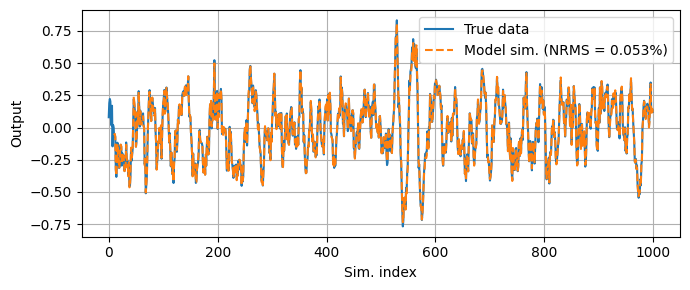

In [6]:
nrmse = NRMSE_loss(Yhat_test[10:], Y_test[10:])  # only consider the part that was not used in state estimation

# visualize model output
sim_idx = np.arange(U_test.shape[0])
plt.figure(figsize=(7,3), layout="tight")
plt.plot(sim_idx, Y_test, label="True data")
plt.plot(sim_idx[10:], Yhat_test[10:], '--', label=f"Model sim. (NRMS = {nrmse:.2}%)")
plt.legend()
plt.grid()
plt.xlabel("Sim. index")
plt.ylabel("Output")
plt.show()

# Contracting LFR-based model augmentation
Another LFR-based model augmentation structure, called contracting LFR, applies a direct parametrization to guarantee stability of the model, regardless of model parameters. More specifically, guarantees contractivity of the resulting model. Training them is practically the same as the well-posed structures:

In [ ]:
# create augmented model
model = StaticContractingLFRAugmentation(known_sys=fp_model, hidden_layers=2, nodes_per_layer=8, activation="tanh", nz=2, nw=2, lipschitz_const=1., norm_dict=norm, fpi_n_max=10, fpi_tol=1e-4)

# set training options
model.set_optimization_parameters(adam_epochs=100, lbfgs_epochs=500, train_x0=True, verbosity=50)

# set ANN Lipschitz regularization
model.set_regularization_terms(ann_lipschitz_regul_coeff=0.1)

# train the model
model.fit(Y_train, U_train)

The contracting parametrization applies a Cayley transform-based computation for multiple matrices in the LFR structure, hence, training them can take significantly longer compared to the simpler approaches. For this small example, training is still finished relatively quickly.

In [8]:
print(f"Model training finished in {model.t_solve} seconds.")

Model training finished in 28.99195408821106 seconds.


The contracting parametrization typically results in a reduced model accuracy, as a trade-off for guaranteed stability. This phenomenon is well-observed also in the black-box setting. Hence, applying such stable-by-design parametrization should always be considered after taking into account all of its drawbacks as well. For the demonstration of the enhanced stability properties, see, e.g., the F1Tenth example.

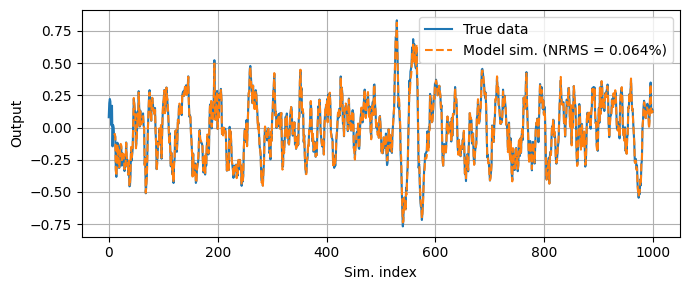

In [9]:
# estimate initial state based on first 10 samples of the test data
x0_test = model.learn_x0(U_test[:10], Y_test[:10], verbosity=False)

# simulate model
Yhat_test, _, iters, residuals = model.simulate(U_test, X0=x0_test)

nrmse = NRMSE_loss(Yhat_test[10:], Y_test[10:])  # only consider the part that was not used in state estimation

# visualize model output
sim_idx = np.arange(U_test.shape[0])
plt.figure(figsize=(7,3), layout="tight")
plt.plot(sim_idx, Y_test, label="True data")
plt.plot(sim_idx[10:], Yhat_test[10:], '--', label=f"Model sim. (NRMS = {nrmse:.2}%)")
plt.legend()
plt.grid()
plt.xlabel("Sim. index")
plt.ylabel("Output")
plt.show()

# Dynamic model augmentation
So far, we have only introduced static model augmentation structures, where only the baseline states, i.e., the states of the first-principles model, are used. However, missing states can also be present in the data-generating system, e.g., corresponding to higher order dynamics, actuator characteristics, etc. For these reasons, the baseline states can be appended with the so-called augmented states, resulting in dynamics augmentation structures. All three previously mentioned structures have a dynamic version, as well. For simplicity, we now only show the dynamic LFR-based augmentation with the constrained $D_\mathrm{zw}$ matrix, but similarly, dynamic well-posed and dynamic contracting structures can also be used.

In [ ]:
# create augmented model
model = DynamicLFRAugmentation(known_sys=fp_model, n_augm_states=1, hidden_layers=2, nodes_per_layer=8, activation="tanh", nz_a=2, nw_a=2, norm_dict=norm, Dzw_structure="lower")

# set training options
model.set_optimization_parameters(adam_epochs=100, lbfgs_epochs=500, train_x0=True, verbosity=50)

# train the model
model.fit(Y_train, U_train)

For static structures, state estimation is not required when full-state measurements are available, or we have information regarding the initial state. However, as the augmented states generally cannot be interpreted as a specific physical variable, state estimation is (almost) always necessary.

Also note that when the baseline states can adequate to describe the dynamics of the data-generating system, then applying additional augmented states is redundanr. For instance, in this example, dynamic augmentation is not necessary and indeed it does not produce more accurate results.

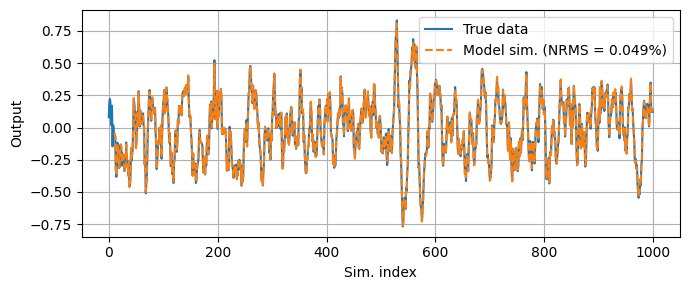

In [11]:
# estimate initial state based on first 10 samples of the test data
x0_test = model.learn_x0(U_test[:10], Y_test[:10], verbosity=False)

# simulate model
Yhat_test, _ = model.simulate(U_test, X0=x0_test)

nrmse = NRMSE_loss(Yhat_test[10:], Y_test[10:])  # only consider the part that was not used in state estimation

# visualize model output
sim_idx = np.arange(U_test.shape[0])
plt.figure(figsize=(7,3), layout="tight")
plt.plot(sim_idx, Y_test, label="True data")
plt.plot(sim_idx[10:], Yhat_test[10:], '--', label=f"Model sim. (NRMS = {nrmse:.2}%)")
plt.legend()
plt.grid()
plt.xlabel("Sim. index")
plt.ylabel("Output")
plt.show()